Q-13 Develop a program to implement the K-Nearest Neighbours (KNN)
algorithm on a given dataset related to student performance with
target as Result(student_performance.csv). The program should
perform the following tasks:

i. Read the given dataset into a dataframe.

ii. Separate the input features and the target class label (Result)

iii. Split the dataset into training and testing sets in the ratios 70:30,
60:40, 80:20.

iv. Implement the K-Nearest Neighbours (KNN) classification
algorithm for a suitable value of K.

v. Train the model using the training data and classify the test
samples.

vi. Evaluate the performance of the model using accuracy, precision,
F1 score and recall and show the confusion matrix.

vii. Use the trained model to predict the class label for new data
points.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [27]:
df = pd.read_csv("student_performance.csv")
df.head()

,StudyHours,Attendance,Assignments,InternalMarks,Result
0,5.6,48,73,64,Pass
1,7.4,45,51,26,Fail
2,3.6,67,36,26,Fail
3,7.2,57,63,68,Pass
4,7.9,88,79,34,Pass


In [28]:
le = LabelEncoder()
df["Result"] = le.fit_transform(df["Result"])

df.head()

,StudyHours,Attendance,Assignments,InternalMarks,Result
0,5.6,48,73,64,1
1,7.4,45,51,26,0
2,3.6,67,36,26,0
3,7.2,57,63,68,1
4,7.9,88,79,34,1


In [29]:
x=df.drop('Result',axis=1)
y=df['Result']
y.value_counts()

,count
Result,
1,200
0,200


In [30]:
ss=StandardScaler()
df_model=pd.DataFrame(ss.fit_transform(x))
x_train,x_test,y_train,y_test=train_test_split(df_model,y,test_size=0.3,random_state=42)

In [31]:
f1_list = []
k_values = range(1, 21)
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    f1 = f1_score(y_test, y_pred)

    f1_list.append(f1)
    print(f"K={k}, f1={f1:.4f}")

K=1, f1=0.9023
K=2, f1=0.8780
K=3, f1=0.8769
K=4, f1=0.8960
K=5, f1=0.9091
K=6, f1=0.9219
K=7, f1=0.9173
K=8, f1=0.9231
K=9, f1=0.9242
K=10, f1=0.9147
K=11, f1=0.9160
K=12, f1=0.9219
K=13, f1=0.9091
K=14, f1=0.9120
K=15, f1=0.9062
K=16, f1=0.9206
K=17, f1=0.9062
K=18, f1=0.9206
K=19, f1=0.9206
K=20, f1=0.9280


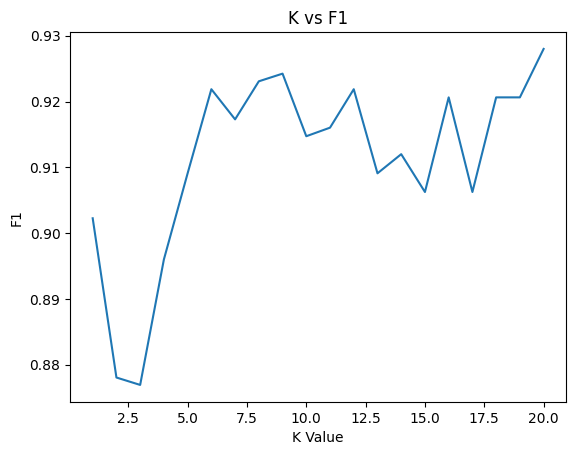

In [32]:
plt.plot(k_values, f1_list)
plt.xlabel("K Value")
plt.ylabel("F1")
plt.title("K vs F1")
plt.show()

In [33]:
best_k = k_values[f1_list.index(max(f1_list))]
print("Best K:", best_k)

Best K: 20


In [34]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [35]:
sizes=[0.2,0.4]
for i in sizes:
  x_train,x_test,y_train,y_test=train_test_split(df_model,y,test_size=i,random_state=42)
  model = KNeighborsClassifier(n_neighbors=best_k)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  conf_matrix = confusion_matrix(y_test, y_pred)
  print(f"Test Size: {i}")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"Confusion Matrix:\n{conf_matrix}")
  print("\n")

Test Size: 0.2
Accuracy: 0.9125
Precision: 0.8913
Recall: 0.9535
F1 Score: 0.9213
Confusion Matrix:
[[32  5]
 [ 2 41]]


Test Size: 0.4
Accuracy: 0.9250
Precision: 0.9639
Recall: 0.8989
F1 Score: 0.9302
Confusion Matrix:
[[68  3]
 [ 9 80]]




In [36]:
new_student = [[5.5, 80, 75, 70]]
new_scaled = ss.transform(new_student)
prediction = model.predict(new_scaled)[0]
print("Prediction:", "Pass" if prediction == 1 else "Fail")

Prediction: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
